In [9]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

In [10]:
def compute_diff(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    # Ensure same shape
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    diff = np.abs(a.astype(np.float32) - b.astype(np.float32))
    return diff

In [11]:
def compute_diff_image(a, b):
    a = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY)
    b = cv2.cvtColor(b, cv2.COLOR_RGB2GRAY)
    a = np.asarray(a)
    b = np.asarray(b)

    # Ensure same shape
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    diff = np.abs(a.astype(np.float32) - b.astype(np.float32))
    return diff

In [12]:
def percent_pixels_different(a, b, threshold=0):
    a = np.asarray(a)
    b = np.asarray(b)

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    # Absolute difference
    diff = np.abs(a.astype(np.float32) - b.astype(np.float32))

    # For RGB images, collapse channel differences
    if diff.ndim == 3:
        diff = diff.max(axis=2)   # or diff.mean(axis=2)

    # Apply threshold
    diff_mask = diff > threshold

    # Percentage of pixels that differ
    return diff_mask.mean() * 100

In [53]:
def show_single_color_heatmap(diff, color="red", threshold=0, percent=0, save_path=None):
    mask = (diff > threshold).astype(np.uint8)
    cmap = ListedColormap(["black", color])
    plt.figure(figsize=(8, 6))
    plt.imshow(mask, cmap=cmap)
    plt.title(f"Pixel Difference: {percent:.2f}%",fontsize=28)
    plt.axis("off")
    if save_path:
        plt.savefig(f'{save_path}.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [54]:
def plot_heatmap(diff):
    # plt.figure(figsize=(8, 6))
    # plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    plt.figure(figsize=(8, 5))
    plt.imshow(diff, cmap="hot")
    cbar = plt.colorbar(label="Difference Intensity")
    # plt.subplots_adjust(bottom=0)
    # ticks = bar.ax.get_yticklabels()
    # ticks[0].set_y(0.5)
    # cbar.ax.tick_params(direction='in')
    # bar.ax.tick_params(pad=10)
    # plt.title("Difference Heatmap")
    # plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    # Remove the bottom tick
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks[1:-1])   # drop the first tick
    # pos = bar.ax.get_position()
    # bar.ax.set_position([pos.x0, pos.y0 + 0.02, pos.width, pos.height])
    plt.axis("off")
    plt.savefig(f'heatmap.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [55]:
def plot_3d_surface_no_color(diff):
    h, w = diff.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(
        X, Y, diff,
        cmap=None,
        color='lightgray',     # uniform color
        edgecolor='none'       # remove grid lines
    )

    ax.set_title("3D Surface of Array Difference (No Colors)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Difference")

    plt.show()

(480, 640, 3)


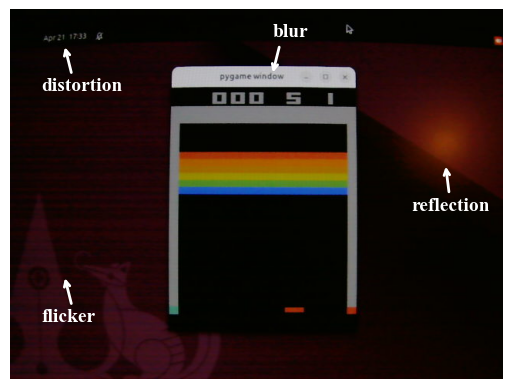

In [56]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./images/original_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.text(
    520, 260, 
    "reflection", 
    color="white", 
    fontsize=14, 
    fontweight="bold"
)

plt.annotate(
    "", 
    xy=(565, 200),          # arrow tip
    xytext=(570, 240),     # arrow tail
    arrowprops=dict(
        arrowstyle="->",
        color="white",
        linewidth=2
    )
)

plt.annotate(
    "", 
    xy=(70, 45),          # arrow tip
    xytext=(80, 85),     # arrow tail
    arrowprops=dict(
        arrowstyle="->",
        color="white",
        linewidth=2
    )
)

plt.text(
    40, 105, 
    "distortion", 
    color="white",
    fontname="Times New Roman",
    fontsize=14, 
    fontweight="bold"
)

plt.annotate(
    "", 
    xy=(70, 345),          # arrow tip
    xytext=(80, 385),     # arrow tail
    arrowprops=dict(
        arrowstyle="->",
        color="white",
        linewidth=2
    )
)

plt.text(
    40, 405, 
    "flicker", 
    color="white",
    fontname="Times New Roman",
    fontsize=14, 
    fontweight="bold"
)

plt.annotate(
    "", 
    xy=(340, 85),          # arrow tip
    xytext=(350, 45),     # arrow tail
    arrowprops=dict(
        arrowstyle="->",
        color="white",
        linewidth=2
    )
)

plt.text(
    340, 35, 
    "blur", 
    color="white",
    fontname="Times New Roman",
    fontsize=14, 
    fontweight="bold"
)

plt.savefig(f'original_file.pdf', bbox_inches='tight')
plt.show()


(480, 640, 3)
Figure size (inches): [6.4 4.8]


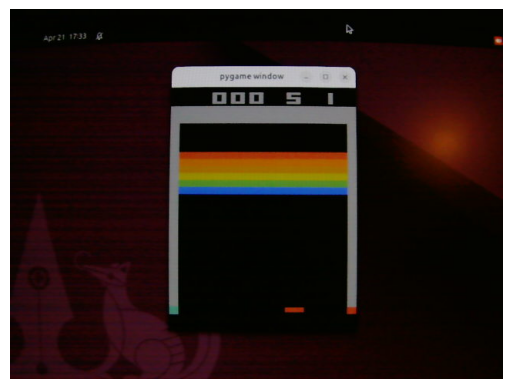

In [57]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./images/original_file.npy")   # shape (H, W, 3)
print(img.shape)

fig, ax = plt.subplots()
plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")
print("Figure size (inches):", fig.get_size_inches())


plt.savefig(f'original_file.png', bbox_inches='tight')
plt.show()


(320, 245, 3)
Figure size (inches): [6.4 4.8]


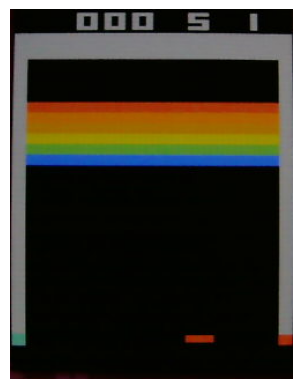

In [58]:
img = np.load("./images/cropped_file.npy")   # shape (H, W, 3)
print(img.shape)

fig, ax = plt.subplots()
plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")
print("Figure size (inches):", fig.get_size_inches())

plt.savefig(f'cropped_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


(210, 160, 3)


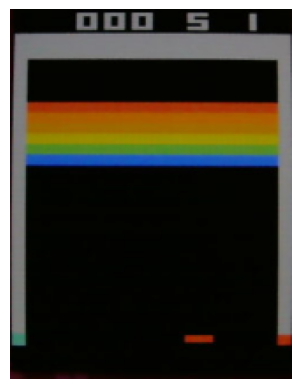

In [59]:
img1 = cv2.resize(img, (160, 210), interpolation=cv2.INTER_AREA)
img3 = img1[:, :, [2, 1, 0]]
# plt.imshow(img1[:, :, [2, 1, 0]].astype(np.uint8))
plt.imshow(img3.astype(np.uint8))
print(img3.shape)
plt.axis("off")
plt.savefig(f'cropped_210x160.pdf', dpi=800, bbox_inches='tight')
plt.show()

(210, 160, 3)


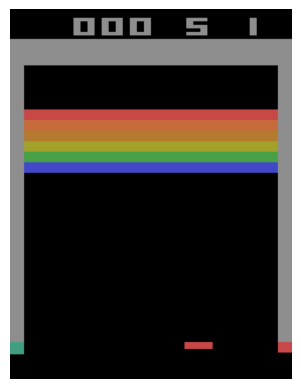

In [60]:
img2 = np.load("./images/env_obs_file.npy")   # shape (H, W, 3)
print(img2.shape)

plt.imshow(img2.astype(np.uint8))
plt.axis("off")
plt.savefig(f'env_obs_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


In [61]:
diff = compute_diff_image(img1, img2)

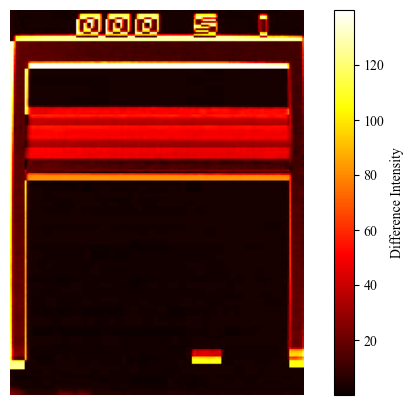

In [62]:
plot_heatmap(diff)

(84, 84)


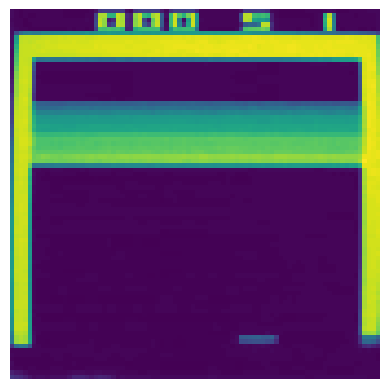

In [63]:
img1 = np.load("./images/preprocessed_file.npy")   # shape (H, W, 3)
print(img1.shape)

plt.imshow(img1.astype(np.uint8))
plt.axis("off")
# plt.savefig(f'preprocessed_file.pdf', dpi=800, bbox_inches='tight')
plt.show()

(84, 84)


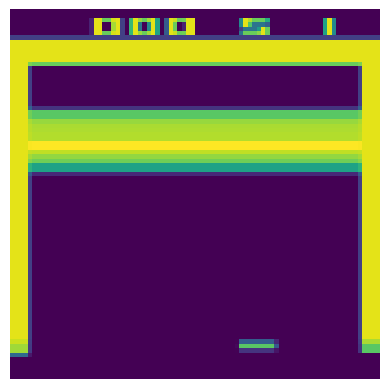

In [64]:
img2 = np.load("./images/obs_resized_file.npy")   # shape (H, W, 3)
print(img2.shape)

plt.imshow(img2.astype(np.uint8))
plt.axis("off")
plt.savefig(f'obs_resized_file.pdf', dpi=800, bbox_inches='tight')
plt.show()


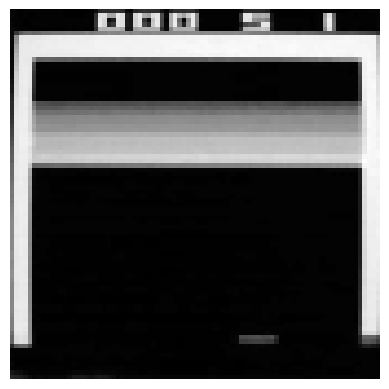

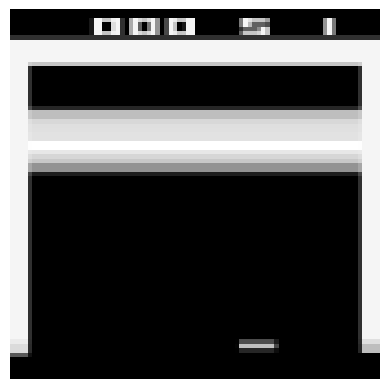

In [65]:
plt.imshow(img1.astype(np.uint8), cmap="gray")
plt.axis("off")
plt.savefig(f'preprocessed_file.pdf', dpi=800, bbox_inches='tight')
plt.show()
plt.imshow(img2.astype(np.uint8), cmap="gray")
plt.axis("off")
plt.savefig(f'obs_resized_file.pdf', dpi=800, bbox_inches='tight')
plt.show()

In [66]:
from mpl_toolkits.mplot3d import Axes3D

In [67]:
percent = percent_pixels_different(img1, img2, threshold=0)
print("Percentage of pixels different:", percent)

Percentage of pixels different: 99.95748299319727


In [68]:
diff = compute_diff(img1, img2)

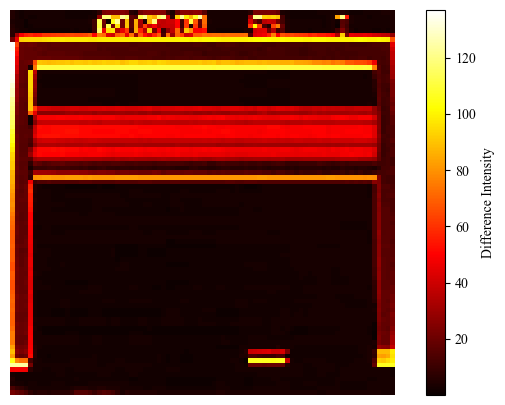

In [69]:
plot_heatmap(diff)

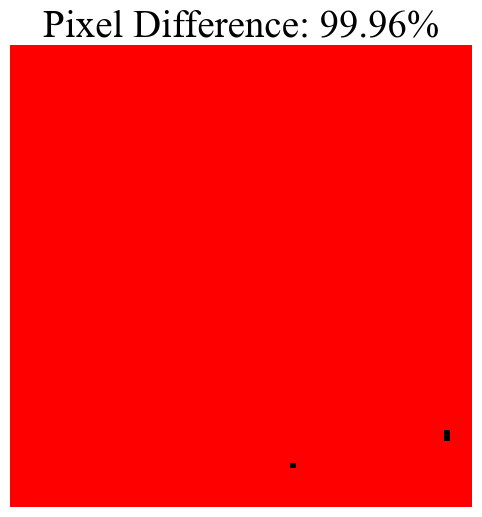

In [70]:
show_single_color_heatmap(diff, color="red", threshold=0, percent=percent, save_path='difference_0')

In [71]:
percent = percent_pixels_different(img1, img2, threshold=10)
print("Percentage of pixels different:", percent)

Percentage of pixels different: 37.38662131519274


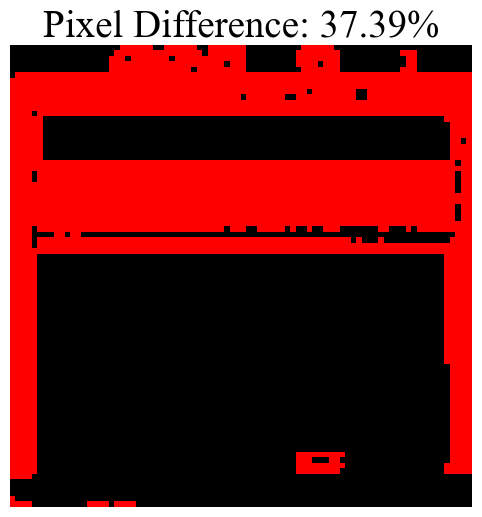

In [72]:
show_single_color_heatmap(diff, color="red", threshold=10, percent=percent, save_path='difference_10')

In [73]:
percent = percent_pixels_different(img1, img2, threshold=20)
print("Percentage of pixels different:", percent)

Percentage of pixels different: 24.41893424036281


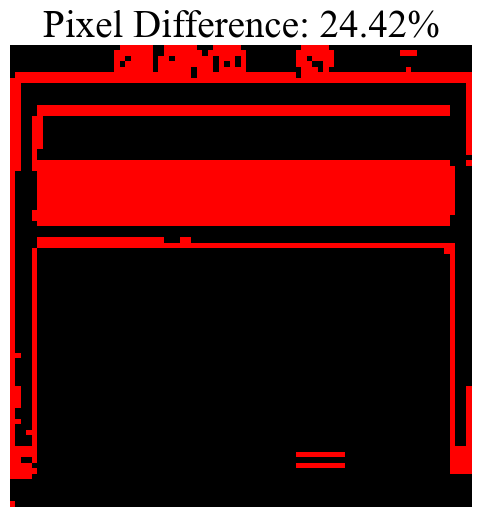

In [74]:
show_single_color_heatmap(diff, color="red", threshold=20, percent=percent, save_path='difference_20')

In [75]:
diff_flippedd = np.flipud(diff)

In [76]:
def plot_3d_surface(diff):
    h, w = diff.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    fig = plt.figure(figsize=(10, 8))
    # fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, diff, cmap="viridis", linewidth=0, antialiased=False)
    # ax.set_title("3D Surface of Array Difference")
    ax.set_xlabel("X", labelpad=12)
    ax.set_ylabel("Y", labelpad=10)
    # ax.set_zlabel("Difference")
    # ax.zaxis.set_rotate_label(False)     # prevent auto-rotation
    ax.set_zlabel("Difference", labelpad=9)
    # ax.view_init(elev=30, azim=-60)
    # ax.zaxis.label.set_position((0.0, 0.0))
    # plt.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
    # plt.savefig(f'3d_surface.pdf', dpi=800, bbox_inches='tight')
    # plt.savefig("3d_surface.pdf", dpi=800, bbox_inches="tight", pad_inches=0.2)
    # plt.savefig("3d_surface.pdf", dpi=800, bbox_inches="tight", pad_inches=0.5)
    # fig.tight_layout(pad=3.0)
    ax.set_box_aspect(None, zoom=0.93)
    ax.set_position([-0.08, 0.02, 0.95, 0.96])
    plt.savefig(f'3d_surface.pdf', dpi=800, bbox_inches='tight')
    plt.show()

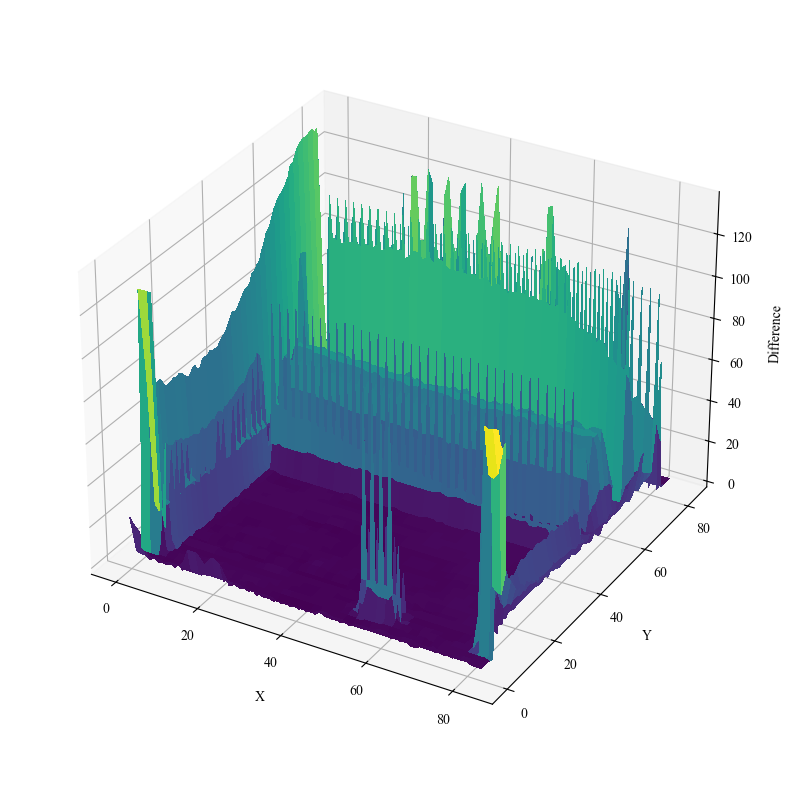

In [77]:
plot_3d_surface(diff_flippedd)

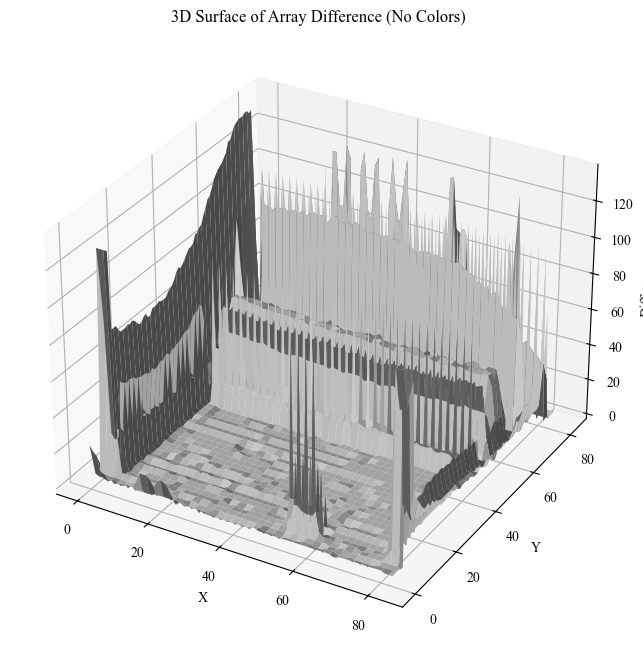

In [78]:
plot_3d_surface_no_color(diff_flippedd)

(480, 640, 3)


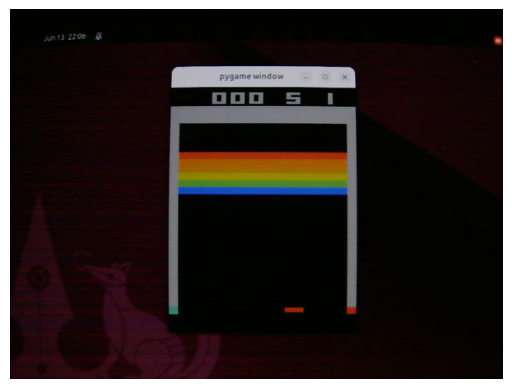

In [79]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./wgzqrmn3/test_result/20260612/original_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'original_file1.png', bbox_inches='tight', pad_inches=0)
plt.show()

(480, 640, 3)


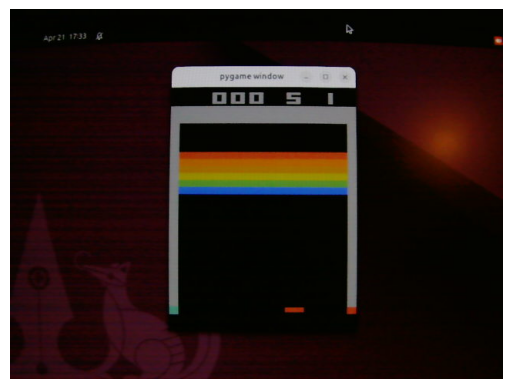

In [80]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./images/original_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")


plt.savefig(f'original_file.png', bbox_inches='tight', pad_inches=0)
plt.show()


(320, 245, 3)


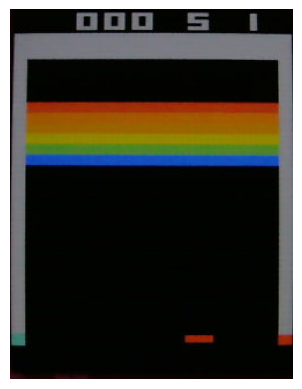

In [81]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./wgzqrmn3/test_result/20260612/cropped_file_105x425.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'cropped_file1.png', bbox_inches='tight', pad_inches=0)
plt.show()


(320, 245, 3)


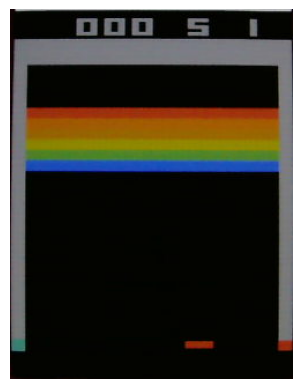

In [82]:
plt.rcParams["font.family"] = "Times New Roman"

img = np.load("./wgzqrmn3/test_result/20260612_5pixels_up/cropped_file_100x420.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'cropped_file2.png', bbox_inches='tight', pad_inches=0)
plt.show()

(320, 245, 3)


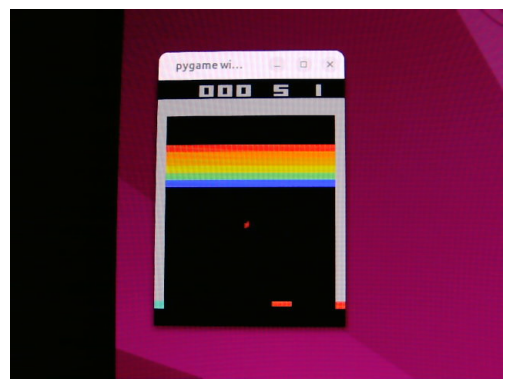

In [83]:
plt.rcParams["font.family"] = "Times New Roman"

img1 = np.load("./10_66_28_74/test_result/20260517/original_file.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img1[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'original_file2.png', bbox_inches='tight', pad_inches=0)
plt.show()

(320, 245, 3)


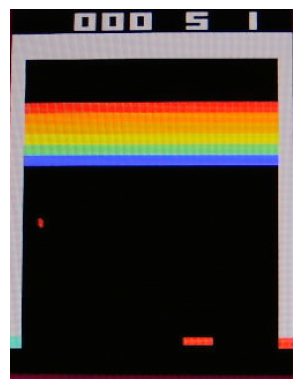

In [84]:
plt.rcParams["font.family"] = "Times New Roman"

img1 = np.load("./10_66_28_74/test_result/20260517/cropped_file_95x415.npy")   # shape (H, W, 3)
print(img.shape)

plt.imshow(img1[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'cropped_file3.png', bbox_inches='tight', pad_inches=0)
plt.show()

(320, 245, 3)


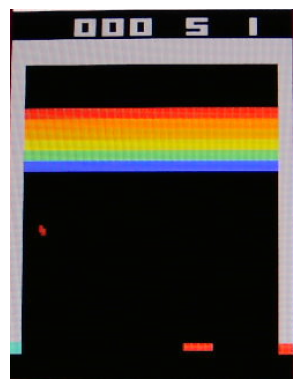

In [85]:
plt.rcParams["font.family"] = "Times New Roman"

img2 = np.load("./10_66_28_74/test_result/20260612_5pixels_up/cropped_file_90x410.npy")   # shape (H, W, 3)
print(img2.shape)

plt.imshow(img2[:, :, [2, 1, 0]].astype(np.uint8))
plt.axis("off")

plt.savefig(f'cropped_file4.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [385]:
diff = compute_diff_image(img1, img2)

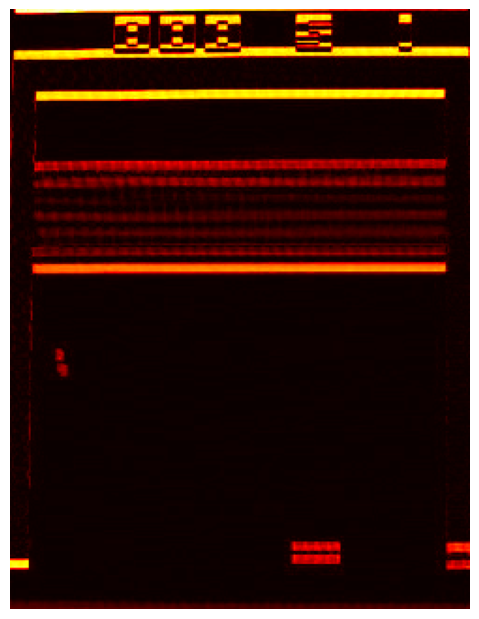

In [386]:
plot_heatmap(diff)